In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

print("Notebook is ready!")

Notebook is ready!


In [2]:
from data_loader import load_data, create_target, handle_missing

df = load_data('../data/ADHD.xlsx')
df = create_target(df)
df = handle_missing(df)

# Quick check
df[['asrs_part_a', 'target']].head(10)

Data loaded successfully — 506 rows, 110 columns
Target created — ADHD Positive: 251, Negative: 255
Missing values handled successfully


,asrs_part_a,target
0,5,0
1,14,1
2,13,0
3,15,1
4,7,0
5,11,0
6,11,0
7,6,0
8,13,0
9,16,1


In [3]:
from feature_engineering import build_feature_matrix, check_class_imbalance
from model import split_data

# Build full feature matrix
X, vectorizer = build_feature_matrix(df)
y = df['target'].values

# Split BEFORE feature selection (very important)
X_train, X_test, y_train, y_test = split_data(X, y)

# Check class imbalance on training set
is_imbalanced = check_class_imbalance(y_train)

Numeric features selected: 20
Categorical features encoded: 4
TF-IDF features created: 100 words/phrases

Full feature matrix: 506 rows x 124 features
Training set : 404 rows
Testing set  : 102 rows

  CLASS IMBALANCE CHECK
  ADHD Negative (0) : 204 (50.5%)
  ADHD Positive (1) : 200 (49.5%)
  Imbalance ratio   : 1.020
  Status: BALANCED — no handling needed


In [4]:
from feature_engineering import apply_feature_selection

# Apply Mutual Info feature selection with k=20
# k=20 was chosen because it gave best accuracy (81.4%) on this dataset
X_train_sel, X_test_sel, selector = apply_feature_selection(
    X_train, y_train, X_test, k=20
)


Applying feature selection...
  Features before selection : 124


C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

  Features after selection  : 20
  Features removed          : 104


C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

In [5]:
from model import train_logistic_regression, train_random_forest, save_model

lr_model = train_logistic_regression(X_train_sel, y_train)
rf_model = train_random_forest(X_train_sel, y_train)

save_model(lr_model, 'logistic_regression.pkl')
save_model(rf_model, 'random_forest.pkl')


Training Logistic Regression...
Logistic Regression trained successfully!

Training Random Forest...
Random Forest trained successfully!
Model saved to: ../models\logistic_regression.pkl
Model saved to: ../models\random_forest.pkl



  Results for: Logistic Regression
  Accuracy  : 81.4%
  F1 Score  : 80.8%
  Precision : 83.3%
  Recall    : 78.4%

Full classification report:
               precision    recall  f1-score   support

ADHD Negative       0.80      0.84      0.82        51
ADHD Positive       0.83      0.78      0.81        51

     accuracy                           0.81       102
    macro avg       0.81      0.81      0.81       102
 weighted avg       0.81      0.81      0.81       102



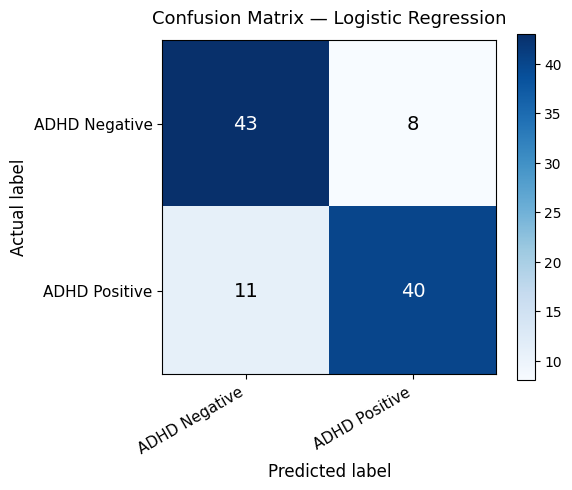

Confusion matrix saved to models/ folder

  Results for: Random Forest
  Accuracy  : 77.5%
  F1 Score  : 76.3%
  Precision : 80.4%
  Recall    : 72.5%

Full classification report:
               precision    recall  f1-score   support

ADHD Negative       0.75      0.82      0.79        51
ADHD Positive       0.80      0.73      0.76        51

     accuracy                           0.77       102
    macro avg       0.78      0.77      0.77       102
 weighted avg       0.78      0.77      0.77       102



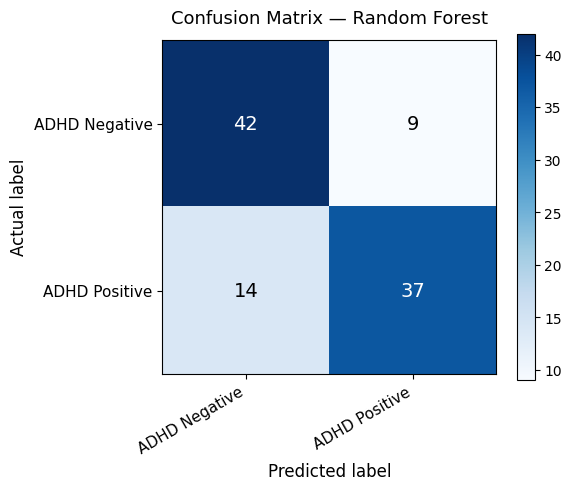

Confusion matrix saved to models/ folder

  MODEL COMPARISON SUMMARY
  Model                       Accuracy       F1   Recall
  --------------------------------------------------
  Logistic Regression            81.4%    80.8%    78.4%
  Random Forest                  77.5%    76.3%    72.5%


In [6]:
from evaluate import evaluate_model, plot_confusion_matrix, compare_models

lr_preds = evaluate_model(lr_model, X_test_sel, y_test, "Logistic Regression")
plot_confusion_matrix(y_test, lr_preds, "Logistic Regression")

rf_preds = evaluate_model(rf_model, X_test_sel, y_test, "Random Forest")
plot_confusion_matrix(y_test, rf_preds, "Random Forest")

compare_models({
    "Logistic Regression": lr_model,
    "Random Forest"      : rf_model
}, X_test_sel, y_test)